## **Best Model:** Random Forest

After evaluating four distinct classification models (Penalized Linear, SVM, Random Forest, and Gradient Boosting), we selected the Random Forest Classifier as our final champion model. While other models like the LinearSVC were more stable (lower variance between training and test scores), they failed to adequately detect health risks, heavily favoring the majority class (Grade A). The Random Forest achieved a Cross-Validation Macro F1 score of 0.56, more than double that of the SVM (~0.23), proving it to be the only model capable of effectively identifying high-risk restaurants (Grades B and C). We prioritized this sensitivity to public health risks over raw model stability.


In [2]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Loading in data: bringing the entire training and test sets
train_df = pd.read_parquet("../data/train_NYC_inspection.parquet")
test_df = pd.read_parquet("../data/test_NYC_inspection.parquet")

# Predictable grade values:
valid_grades = ['A', 'B', 'C', 'N','P','Z']

# Filter Training Data
train_df = train_df[train_df['GRADE'].isin(valid_grades)].copy()
X_train = train_df.drop(columns=['GRADE']) # removing target variable as well as score 
# since it is used to determine grade
y_train = train_df['GRADE'] # target variable, we are predicting GRADE

# Same Filtering for Test Data:
test_df_clean = test_df[test_df['GRADE'].isin(valid_grades)].copy()
X_test = test_df_clean.drop(columns=['GRADE'])
y_test = test_df_clean['GRADE']

# Print dimensions for datasets:
print(f"Training Shape: {train_df.shape}")
print(f"Testing Shape (Cleaned): {test_df_clean.shape}")

Training Shape: (68423, 9)
Testing Shape (Cleaned): (17053, 9)


In [3]:
# --- FINAL MODEL TRAINING AND EVALUATION ---

# Using best model: Random Forest from previous hyperparameter tuning
# Using the best parameters determined (for RandomForest): C=0.1, class_weight='balanced'
numeric_features = ['Latitude', 'Longitude', 'ZIPCODE']
categorical_features = ['CUISINE DESCRIPTION', 'BORO']

# ---- PIPELINES ---- 
# Using pipelines to handle preprocessing more efficiently 

# Numeric pipeline:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # imputing missing values with median for numeric
    ('scaler', StandardScaler()) # standardizing numeric features
])

# Categorical pipeline:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # imputing missing values with most frequent for categorical
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # one-hot encoding categorical features
])

# Combining both pipelines:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
])

# ---- FINAL MODEL PIPELINE ----
# Best Model: Random Forest
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        # --- MATCHING YOUR BEST PARAMETERS ---
        n_estimators=100,
        max_depth=20,
        max_features='sqrt',
        min_samples_leaf=2,
        min_samples_split=5,
        # -------------------------------------
        random_state=42,
        n_jobs=-1,
        class_weight='balanced' # just as an additional precaution
    ))
])

# FITTING on the FULL TRAINING SET:
print("Training Final Model (Random Forest):")
final_model.fit(X_train, y_train)

# Evaluate training performance:
print("\n--- TRAINING SET PERFORMANCE ---")
y_train_pred = final_model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_acc:.4f}")

# PREDICTION on the TEST SET:
print("\n--- TEST SET PERFORMANCE ---")
y_test_pred = final_model.predict(X_test)
print(classification_report(y_test, y_test_pred))

# Printing out our final evaluation metrics:
print("\n=== FINAL TEST SET RESULTS ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

Training Final Model (Random Forest):

--- TRAINING SET PERFORMANCE ---
Training Accuracy: 0.8639

--- TEST SET PERFORMANCE ---
              precision    recall  f1-score   support

           A       0.96      0.79      0.87     10791
           B       0.66      0.79      0.72      2038
           C       0.61      0.84      0.71      1590
           N       0.71      0.89      0.79      1323
           P       0.08      0.30      0.13        80
           Z       0.63      0.81      0.71      1231

    accuracy                           0.80     17053
   macro avg       0.61      0.74      0.65     17053
weighted avg       0.84      0.80      0.81     17053


=== FINAL TEST SET RESULTS ===
Accuracy: 0.8019116870931801

Classification Report:
               precision    recall  f1-score   support

           A       0.96      0.79      0.87     10791
           B       0.66      0.79      0.72      2038
           C       0.61      0.84      0.71      1590
           N       0.71   

<Figure size 800x600 with 0 Axes>

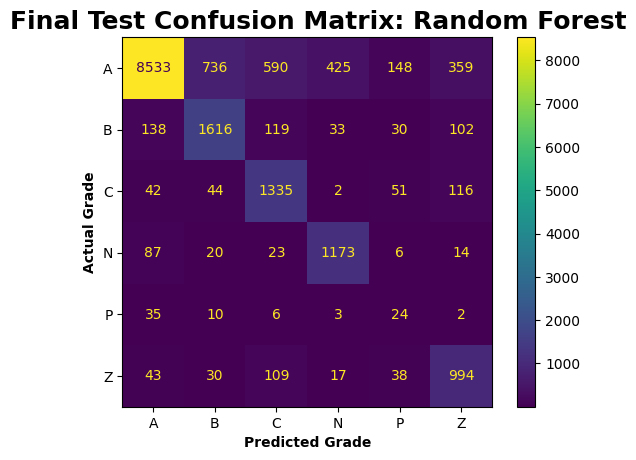

In [4]:
# Confusion Matrix:
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)
disp.plot()

# Formatting:
plt.title('Final Test Confusion Matrix: Random Forest',  weight='bold', fontsize=18, x = 0.53)
plt.xlabel('Predicted Grade',  weight='bold')
plt.ylabel('Actual Grade',  weight='bold')
plt.savefig("../output/figures/final_test_confusion_matrix_RandomForest.png", dpi=300)
plt.show()


### **Final Evaluation:** 

Our Random Forest model achieved a test accuracy of ~80.2%, with a macro F1 score of ~65%. While this gap indicates some overfitting (the model memorized some training noise), this trade-off was necessary to achieve our primary goal. The "stable" models (like LinearSVC) were underfitting—they simply guessed "Grade A" for everyone to stay safe, with not much regards to the other classes (Macro F1 ~0.23).

The most critical metric for this project is the Macro F1 Score, which measures how well the model balances performance across all grades, not just the majority. The Random Forest achieved a Macro F1 of 0.65, which is more than double the performance of the LinearSVC (~0.23).

As seen in the Confusion Matrix above, the Random Forest successfully identifies a significant volume of Grade 'B' and 'C' restaurants (the diagonal values). In contrast, previous models failed to identify these risks almost entirely. For a health department, a model that overfits but correctly flags violators is far more valuable than a stable model that misses every health hazard.